## Import the Model

In [1]:
import sys
sys.path.append('../')

import src.TagModel as model
import src.TagModel_lat as model_latency
import src.Auth as Auth
import utils.utils as utils
import numpy as np
import matplotlib.pyplot as plt 
import json
import os
import threading

### Run the Model

Just considering the E[A]

In [ ]:
m_nrs = [20,30]
t_nrs = [5,10,15]
p = [.95, .9, .85, .8, .75, .7]
q = [1]


def run_optimize(parameters):
    os.system("python3 optimize.py \'"+json.dumps(parameters)+"\'")

threads = []
for m_nr in m_nrs:
    for t_nr in t_nrs:
        for p_ in p:
            for q_ in q:
                parameters = {'m_nr': m_nr, 't_nr': t_nr, 
                              'p': p_, 'q': q_, 
                              'TagEveryMessage': True, 
                              'AtLeastOnce': False, 
                              'EquivalentA': True}
                threads.append(threading.Thread(target=run_optimize, args=(parameters,)))
                threads[-1].start() 
        cnt = 0
        for thread in threads:
            thread.join()
            cnt += 1
            print(cnt)
            
                # exp = utils.Run_Experiment(model        = model.math_model,
                #                            parameters   = parameters,
                #                            eval         = Auth.evaluate,
                #                            m_size       = 128,
                #                            t_size       = 256,
                #                            save         = True)


# parameters = {'m_nr': 25, 't_nr': 25, 
#               'p': 0.95, 'q': 1, 
#               'TagEveryMessage': True, 
#               'AtLeastOnce': False, 
#               'EquivalentA': True}

# exp = utils.Run_Experiment(model        = model.math_model,
#                            parameters   = parameters,
#                            eval         = Auth.evaluate,
#                            m_size       = 1024,
#                            t_size       = 256,
#                            save         = True)
# exp['eval']




### Looking at the saved Models

In [ ]:
exp = utils.Load_Experiments()

import seaborn as sns

for i in range(len(exp)):
    print(exp[i]['parameters'])
    print(exp[i]['eval'])
    sns.heatmap(exp[i]['results']['X'])
    plt.show()
    print('\n\n')

### Creating a  progressive MAC for comparison

In [4]:
plot = False

### AGG MAC x ###
def AGG_MAC_x(m_nr, x):
    X = np.zeros((m_nr, m_nr//x))
    for i in range(m_nr):
        X[i, i//x] = 1
    return X


for x in [2,3,4,5]:
    X = AGG_MAC_x(35-35%x,x)

    for i in [.7, .8 , .9]:
        parameters = {'m_nr': X.shape[0], 't_nr': X.shape[1],
                        'p': i, 'q': 1,
                        'x': x,
                        'name': f'AggMAC_{x}'}
        exp = Auth.Create_Experiment(parameters,X= X)
        exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256, security_requirments=256, plot=plot)
        if utils.Save_Experiment(exp) != True:
            print("Error saving experiment AggMAC" , "with parameters", parameters)

print("AGG MAC experiments done")

for i in [.7, .8 , .9]:
    parameters = {'m_nr': 20, 't_nr': 20,
                    'p': i, 'q': 1, 
                    'name': 'trad'}

    exp = Auth.Create_Experiment(parameters,X= np.eye(parameters['m_nr']))
    exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256, security_requirments=256, plot=plot)
    if utils.Save_Experiment(exp) != True:
        print("Error saving experiment trad" , "with parameters", parameters)

    print("Traditional MAC experiments done")

    for x in [2,3,4,5]:

        parameters = {'m_nr': 20, 't_nr': 20,
                        'p': i, 'q': 1,
                        'x': x,
                        'name': f'Whip_{x}'}
        X = Auth.ProMAC_X(parameters['m_nr'],parameters['x'])
        exp = Auth.Create_Experiment(parameters,X= X)
        exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256/parameters['x'], security_requirments=256, plot=plot)
        if utils.Save_Experiment(exp) != True:
            print("Error saving experiment ProMAC" , "with parameters", parameters)

Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment saved as experiment number 36
Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment saved as experiment number 37
Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment saved as experiment number 38
Status: 1
Objective value: 11.0
Status: 1
Objective value: 11.0
Experiment saved as experiment number 39
Status: 1
Objective value: 11.0
Status: 1
Objective value: 11.0
Experiment saved as experiment number 40
Status: 1
Objective value: 11.0
Status: 1
Objective value: 11.0
Experiment saved as experiment number 41
Status: 1
Objective value: 8.0
Status: 1
Objective value: 8.0
Experiment saved as experiment number 42
Status: 1
Objective value: 8.0
Status: 1
Objective value: 8.0
Experiment saved as experiment number 43
Status: 1
Objective value: 8.0
Status: 1
Objective value: 8.0
Experiment saved as experiment number 44
Status: 1
Objective value: 7.0
Status: 1
Objective value: 7.0

{'m_nr': 20, 't_nr': 5, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.31640625, 0.31640625, 0.31640625, 0.31640625, 0.31640625,
       0.31640625, 0.31640625, 0.31640625, 0.31640625, 0.31640625,
       0.31640625, 0.31640625, 0.31640625, 0.31640625, 0.31640625,
       0.31640625, 0.31640625, 0.31640625, 0.31640625, 0.31640625]), 'L': array([17, 18,  9, 14, 15, 11,  5,  4,  9,  9,  9,  0,  6,  3,  2,  3,  0,
        0,  0,  0]), 'average_A': 0.31640625, 'average_L': 6.7, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.6666666666666666, 'goodput_with_tag_adjustment': 0.6666666666666666, 'security_goodput': 0.31640625, 'rows_that_breaks_the_verification': [2, 12, 13, 17, 18]}


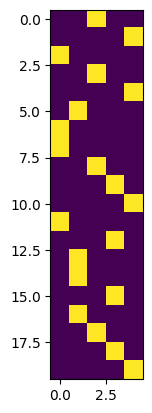




{'m_nr': 20, 't_nr': 5, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096,
       0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096,
       0.4096, 0.4096, 0.4096, 0.4096]), 'L': array([19, 12, 17, 10,  8,  8, 12,  5,  4,  9,  7,  6,  0,  0,  3,  4,  2,
        0,  0,  0]), 'average_A': 0.4096000000000001, 'average_L': 6.3, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.6666666666666666, 'goodput_with_tag_adjustment': 0.6666666666666666, 'security_goodput': 0.4096000000000001, 'rows_that_breaks_the_verification': [4, 13, 16, 17, 18]}


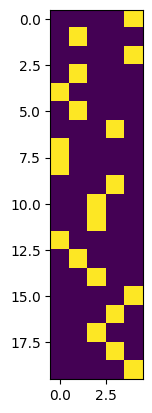




{'m_nr': 20, 't_nr': 5, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401,
       0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401,
       0.2401, 0.2401, 0.2401, 0.2401]), 'L': array([14, 13,  9, 16,  7, 11,  8,  4,  8,  9,  8,  0,  4,  5,  0,  4,  0,
        2,  0,  0]), 'average_A': 0.24009999999999992, 'average_L': 6.1, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.6666666666666666, 'goodput_with_tag_adjustment': 0.6666666666666666, 'security_goodput': 0.24009999999999992, 'rows_that_breaks_the_verification': [2, 4, 5, 9, 11]}


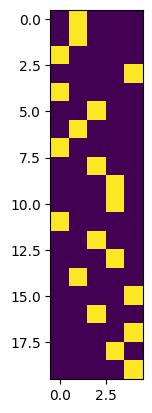




{'m_nr': 20, 't_nr': 5, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.79242961, 1.79242961, 1.79242961, 1.79242961, 1.79242961,
       1.79242961, 1.79242961, 1.79242961, 1.79242961, 1.79242961,
       1.79242961, 1.79242961, 1.79242961, 1.79242961, 1.79242961,
       1.79242961, 1.79242961, 1.79242961, 1.79242961, 1.79242961]), 'L': array([19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,
        2,  1,  0]), 'average_A': 1.792429612042709, 'average_L': 9.5, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.6666666666666666, 'goodput_with_tag_adjustment': 0.7828746177370031, 'security_goodput': 1.0000000000000002, 'rows_that_breaks_the_verification': [2]}


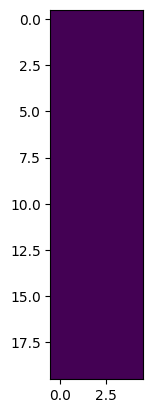




{'m_nr': 20, 't_nr': 5, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.54498105, 0.54498105, 0.54498105, 0.54498105, 0.54498105,
       0.54498105, 0.54498105, 0.54498105, 0.54498105, 0.54498105,
       0.54498105, 0.54498105, 0.54498105, 0.54498105, 0.54498105,
       0.54498105, 0.54498105, 0.54498105, 0.54498105, 0.54498105]), 'L': array([18, 17, 16, 12, 14, 13,  9,  8, 10,  6,  5,  7,  6,  2,  1,  0,  2,
        1,  0,  0]), 'average_A': 0.5449810500781248, 'average_L': 7.35, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.6666666666666666, 'goodput_with_tag_adjustment': 0.6666666666666666, 'security_goodput': 0.5449810500781248, 'rows_that_breaks_the_verification': [1, 4, 5]}


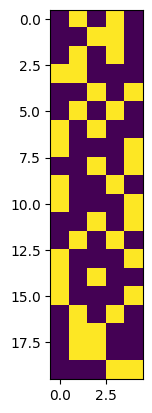




{'m_nr': 20, 't_nr': 5, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.86093442, 0.86093442, 0.86093442, 0.86093442, 0.86093442,
       0.86093442, 0.86093442, 0.86093442, 0.86093442, 0.86093442,
       0.86093442, 0.86093442, 0.86093442, 0.86093442, 0.86093442,
       0.86093442, 0.86093442, 0.86093442, 0.86093442, 0.86093442]), 'L': array([17, 16, 16, 13, 15, 11, 11,  9,  8,  8,  7,  5,  4,  6,  2,  3,  0,
        0,  0,  0]), 'average_A': 0.8609344200000002, 'average_L': 7.55, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.6666666666666666, 'goodput_with_tag_adjustment': 0.6666666666666666, 'security_goodput': 0.8609344200000002, 'rows_that_breaks_the_verification': [2, 3, 4]}


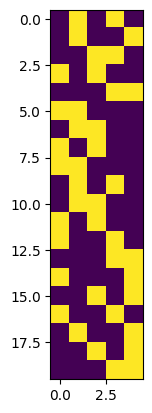




{'m_nr': 20, 't_nr': 10, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922]), 'L': array([19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,
        2,  1,  0]), 'average_A': 3.584859224085419, 'average_L': 9.5, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.7828746177370031, 'security_goodput': 0.9999999999999998, 'rows_that_breaks_the_verification': [2]}


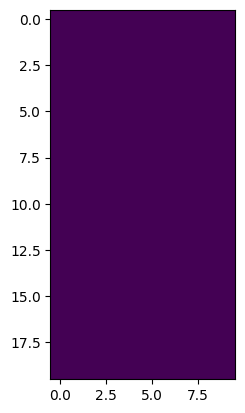




{'m_nr': 20, 't_nr': 10, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125]), 'L': array([15,  9, 15, 14,  6, 14,  6, 10,  8,  1,  0,  4,  0,  5,  4,  0,  0,
        0,  0,  0]), 'average_A': 0.6328125, 'average_L': 5.55, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5, 'security_goodput': 0.6328125, 'rows_that_breaks_the_verification': [4, 9, 10, 13, 15]}


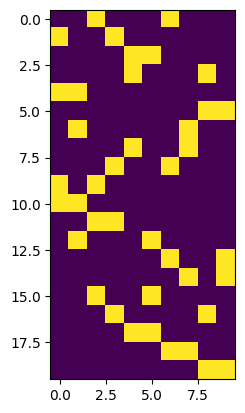




{'m_nr': 20, 't_nr': 10, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855]), 'L': array([13, 15, 15, 10,  9,  8, 11,  8,  7,  7,  3,  5,  5,  0,  1,  0,  0,
        0,  0,  0]), 'average_A': 1.1314485468749997, 'average_L': 5.85, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5311203319502075, 'security_goodput': 0.9999999999999998, 'rows_that_breaks_the_verification': [2, 4, 8, 14]}


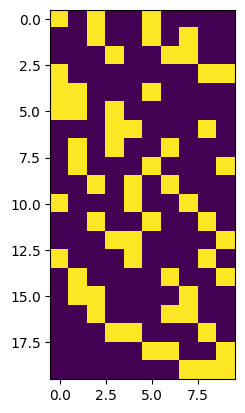




{'m_nr': 20, 't_nr': 10, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192,
       0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192,
       0.8192, 0.8192, 0.8192, 0.8192]), 'L': array([16, 17, 15, 14, 10, 13,  6,  8,  7,  5,  2,  1,  0,  5,  0,  0,  0,
        0,  0,  0]), 'average_A': 0.8192000000000002, 'average_L': 5.95, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5, 'security_goodput': 0.8192000000000002, 'rows_that_breaks_the_verification': [2, 3, 9, 11, 17]}


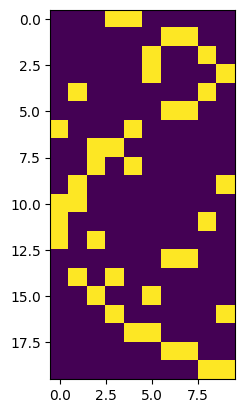




{'m_nr': 20, 't_nr': 10, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922]), 'L': array([16, 15, 14, 13, 12, 13, 12,  9,  8,  7,  6,  5,  4,  3,  2,  3,  0,
        1,  0,  0]), 'average_A': 1.7433922005000007, 'average_L': 7.15, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.6368159203980099, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [14, 19]}


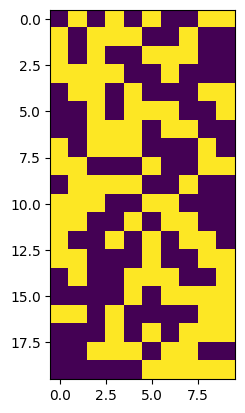




{'m_nr': 20, 't_nr': 10, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49,
       0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49]), 'L': array([ 7,  9,  4,  9,  5, 14,  0,  0,  9,  0,  0,  3,  0,  5,  0,  1,  0,
        0,  0,  0]), 'average_A': 0.48999999999999994, 'average_L': 3.3, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5, 'security_goodput': 0.48999999999999994, 'rows_that_breaks_the_verification': [4, 7, 8, 9, 10, 11, 12, 16, 19, 20]}


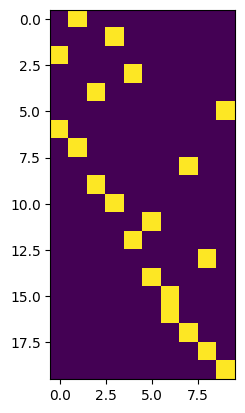




{'m_nr': 20, 't_nr': 15, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([5.37728884, 5.37728884, 5.37728884, 5.37728884, 5.37728884,
       5.37728884, 5.37728884, 5.37728884, 5.37728884, 5.37728884,
       5.37728884, 5.37728884, 5.37728884, 5.37728884, 5.37728884,
       5.37728884, 5.37728884, 5.37728884, 5.37728884, 5.37728884]), 'L': array([19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,
        2,  1,  0]), 'average_A': 5.377288836128128, 'average_L': 9.5, 'computation_(tag to message ratio)': 0.75, 'goodput_without_tag_adjustment': 0.4, 'goodput_with_tag_adjustment': 0.7840735068912711, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [2]}


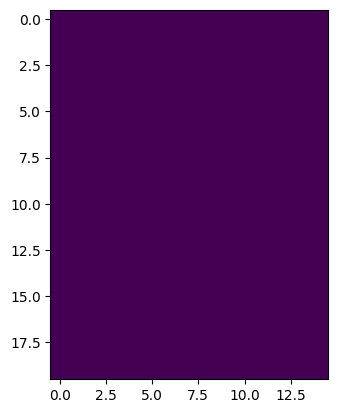




{'m_nr': 20, 't_nr': 15, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.94921875, 0.94921875, 0.94921875, 0.94921875, 0.94921875,
       0.94921875, 0.94921875, 0.94921875, 0.94921875, 0.94921875,
       0.94921875, 0.94921875, 0.94921875, 0.94921875, 0.94921875,
       0.94921875, 0.94921875, 0.94921875, 0.94921875, 0.94921875]), 'L': array([ 9, 10, 14, 12,  7,  6,  3,  2,  7,  0,  4,  0,  2,  1,  0,  0,  0,
        0,  0,  0]), 'average_A': 0.94921875, 'average_L': 3.85, 'computation_(tag to message ratio)': 0.75, 'goodput_without_tag_adjustment': 0.4, 'goodput_with_tag_adjustment': 0.4, 'security_goodput': 0.94921875, 'rows_that_breaks_the_verification': [3, 6, 7, 9, 13, 20]}


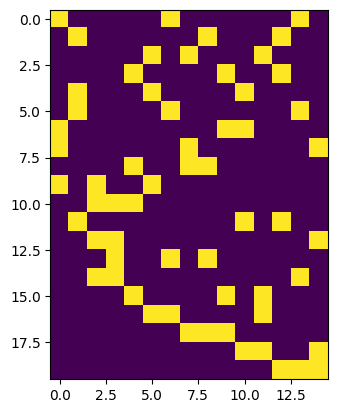




{'m_nr': 20, 't_nr': 15, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.2288, 1.2288, 1.2288, 1.2288, 1.2288, 1.2288, 1.2288, 1.2288,
       1.2288, 1.2288, 1.2288, 1.2288, 1.2288, 1.2288, 1.2288, 1.2288,
       1.2288, 1.2288, 1.2288, 1.2288]), 'L': array([13, 15,  7, 10,  5, 10,  3,  5,  8,  0,  5,  1,  0,  0,  1,  0,  0,
        0,  0,  0]), 'average_A': 1.2288000000000001, 'average_L': 4.15, 'computation_(tag to message ratio)': 0.75, 'goodput_without_tag_adjustment': 0.4, 'goodput_with_tag_adjustment': 0.4507042253521127, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [2, 4, 5, 7, 13, 19]}


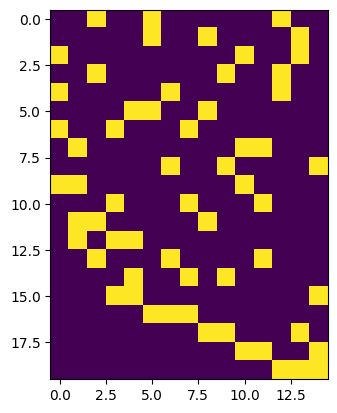




{'m_nr': 20, 't_nr': 15, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.7203, 0.7203, 0.7203, 0.7203, 0.7203, 0.7203, 0.7203, 0.7203,
       0.7203, 0.7203, 0.7203, 0.7203, 0.7203, 0.7203, 0.7203, 0.7203,
       0.7203, 0.7203, 0.7203, 0.7203]), 'L': array([13, 13, 13, 10, 11,  7,  8,  6,  7,  8,  2,  1,  0,  0,  0,  0,  0,
        0,  0,  0]), 'average_A': 0.7202999999999997, 'average_L': 4.95, 'computation_(tag to message ratio)': 0.75, 'goodput_without_tag_adjustment': 0.4, 'goodput_with_tag_adjustment': 0.4, 'security_goodput': 0.7202999999999997, 'rows_that_breaks_the_verification': [4, 7, 10, 12, 16]}


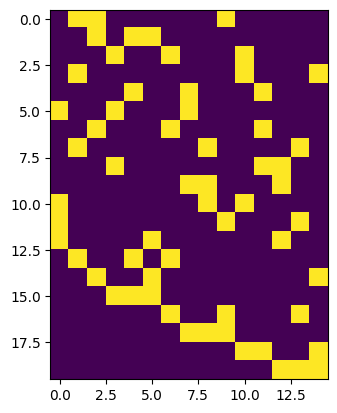




{'m_nr': 20, 't_nr': 15, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([2.59571728, 2.59571728, 2.59571728, 2.59571728, 2.59571728,
       2.59571728, 2.59571728, 2.59571728, 2.59571728, 2.98313777,
       2.59571728, 2.59571728, 2.59571728, 2.59571728, 2.59571728,
       2.59571728, 2.59571728, 2.59571728, 2.59571728, 2.59571728]), 'L': array([13, 12, 11, 10,  9,  9, 12,  7,  5,  5,  3,  2,  2,  0,  0,  2,  1,
        0,  0,  0]), 'average_A': 2.6150883007500005, 'average_L': 5.15, 'computation_(tag to message ratio)': 0.75, 'goodput_without_tag_adjustment': 0.4, 'goodput_with_tag_adjustment': 0.6376089663760897, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [7, 9, 10]}


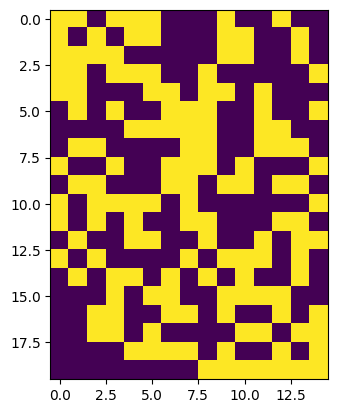




{'m_nr': 20, 't_nr': 15, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.6764296, 1.6764296, 1.6764296, 1.6764296, 1.6764296, 1.6764296,
       1.6764296, 1.6764296, 1.6764296, 1.6764296, 1.6764296, 1.6764296,
       1.6764296, 1.6764296, 1.6764296, 1.6764296, 1.6764296, 1.6764296,
       1.6764296, 1.6764296]), 'L': array([16, 16, 16, 12, 11, 11,  9,  8,  7,  6,  6,  4,  5,  4,  1,  0,  0,
        0,  0,  0]), 'average_A': 1.6764295969531244, 'average_L': 6.6, 'computation_(tag to message ratio)': 0.75, 'goodput_without_tag_adjustment': 0.4, 'goodput_with_tag_adjustment': 0.5289256198347108, 'security_goodput': 0.9999999999999998, 'rows_that_breaks_the_verification': [4, 7, 13, 20]}


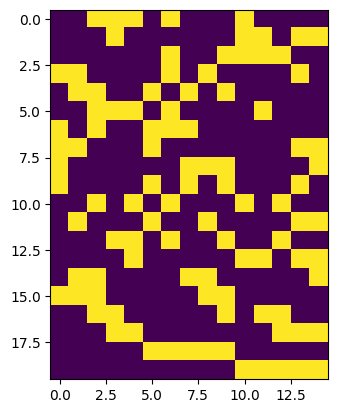




{'m_nr': 30, 't_nr': 5, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.37714952, 0.37714952, 0.37714952, 0.37714952, 0.37714952,
       0.37714952, 0.37714952, 0.37714952, 0.37714952, 0.37714952,
       0.37714952, 0.37714952, 0.37714952, 0.37714952, 0.37714952,
       0.37714952, 0.37714952, 0.37714952, 0.37714952, 0.37714952,
       0.37714952, 0.37714952, 0.37714952, 0.37714952, 0.37714952,
       0.37714952, 0.37714952, 0.37714952, 0.37714952, 0.37714952]), 'L': array([29, 25, 23, 24, 20, 20, 18, 19, 16, 15, 15, 16, 14, 14, 11, 14, 13,
        8,  8,  5,  7,  6,  4,  6,  0,  0,  0,  0,  1,  0]), 'average_A': 0.3771495156249999, 'average_L': 11.7, 'computation_(tag to message ratio)': 0.16666666666666666, 'goodput_without_tag_adjustment': 0.75, 'goodput_with_tag_adjustment': 0.75, 'security_goodput': 0.3771495156249999, 'rows_that_breaks_the_verification': [13, 14, 16, 20, 26]}


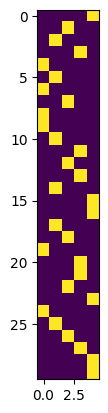




{'m_nr': 30, 't_nr': 5, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.262144, 0.262144, 0.262144, 0.262144, 0.262144, 0.262144,
       0.262144, 0.262144, 0.262144, 0.262144, 0.262144, 0.262144,
       0.262144, 0.262144, 0.262144, 0.262144, 0.262144, 0.262144,
       0.262144, 0.262144, 0.262144, 0.262144, 0.262144, 0.262144,
       0.262144, 0.262144, 0.262144, 0.262144, 0.262144, 0.262144]), 'L': array([25, 24, 17, 14, 13, 20, 21, 22, 11, 18,  9,  6,  7,  4, 13,  2, 13,
        0,  1,  0,  7,  8,  3,  4,  1,  0,  3,  0,  1,  0]), 'average_A': 0.2621440000000001, 'average_L': 8.9, 'computation_(tag to message ratio)': 0.16666666666666666, 'goodput_without_tag_adjustment': 0.75, 'goodput_with_tag_adjustment': 0.75, 'security_goodput': 0.2621440000000001, 'rows_that_breaks_the_verification': [1, 14, 15, 19, 30]}


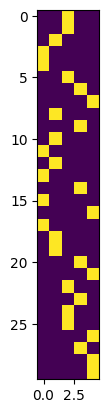




{'m_nr': 30, 't_nr': 5, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.17797852, 0.17797852, 0.17797852, 0.17797852, 0.17797852,
       0.17797852, 0.17797852, 0.17797852, 0.17797852, 0.17797852,
       0.17797852, 0.17797852, 0.17797852, 0.17797852, 0.17797852,
       0.17797852, 0.17797852, 0.17797852, 0.17797852, 0.17797852,
       0.17797852, 0.17797852, 0.17797852, 0.17797852, 0.17797852,
       0.17797852, 0.17797852, 0.17797852, 0.17797852, 0.17797852]), 'L': array([27, 20, 19, 18, 22, 21, 22, 20, 18, 19, 11, 17,  9, 15, 15, 14, 13,
       12,  8,  9,  7,  0,  4,  6,  3,  2,  0,  0,  0,  0]), 'average_A': 0.177978515625, 'average_L': 11.7, 'computation_(tag to message ratio)': 0.16666666666666666, 'goodput_without_tag_adjustment': 0.75, 'goodput_with_tag_adjustment': 0.75, 'security_goodput': 0.177978515625, 'rows_that_breaks_the_verification': [10, 11, 15, 21, 23]}


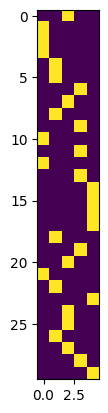




{'m_nr': 30, 't_nr': 5, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.117649, 0.117649, 0.117649, 0.117649, 0.117649, 0.117649,
       0.117649, 0.117649, 0.117649, 0.117649, 0.117649, 0.117649,
       0.117649, 0.117649, 0.117649, 0.117649, 0.117649, 0.117649,
       0.117649, 0.117649, 0.117649, 0.117649, 0.117649, 0.117649,
       0.117649, 0.117649, 0.117649, 0.117649, 0.117649, 0.117649]), 'L': array([27, 28, 19, 21, 24, 24, 23, 14, 16, 12, 18, 16, 12, 14, 14,  6, 11,
        4, 11,  5,  8,  0,  2,  5,  0,  4,  1,  0,  0,  0]), 'average_A': 0.11764899999999998, 'average_L': 11.3, 'computation_(tag to message ratio)': 0.16666666666666666, 'goodput_without_tag_adjustment': 0.75, 'goodput_with_tag_adjustment': 0.75, 'security_goodput': 0.11764899999999998, 'rows_that_breaks_the_verification': [2, 11, 16, 23, 27]}


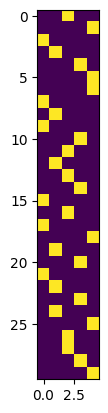




{'m_nr': 30, 't_nr': 5, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.56485907, 0.56485907, 0.56485907, 0.56485907, 0.56485907,
       0.56485907, 0.56485907, 0.56485907, 0.56485907, 0.56485907,
       0.56485907, 0.56485907, 0.56485907, 0.56485907, 0.56485907,
       0.56485907, 0.56485907, 0.56485907, 0.56485907, 0.56485907,
       0.56485907, 0.56485907, 0.56485907, 0.56485907, 0.56485907,
       0.56485907, 0.56485907, 0.56485907, 0.56485907, 0.56485907]), 'L': array([27, 13, 12, 11, 10,  9,  8,  7,  6, 19, 18,  3,  2,  1,  0, 12, 11,
       11, 10, 10,  8,  7,  6,  6,  3,  2,  2,  0,  0,  0]), 'average_A': 0.5648590729620006, 'average_L': 7.8, 'computation_(tag to message ratio)': 0.16666666666666666, 'goodput_without_tag_adjustment': 0.75, 'goodput_with_tag_adjustment': 0.75, 'security_goodput': 0.5648590729620006, 'rows_that_breaks_the_verification': [1, 2, 18]}


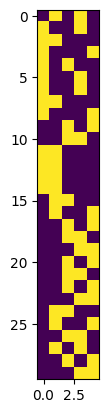




{'m_nr': 30, 't_nr': 5, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.19164296, 1.19164296, 1.19164296, 1.19164296, 1.19164296,
       1.19164296, 1.19164296, 1.19164296, 1.19164296, 1.19164296,
       1.19164296, 1.19164296, 1.19164296, 1.19164296, 1.19164296,
       1.19164296, 1.19164296, 1.19164296, 1.19164296, 1.19164296,
       1.19164296, 1.19164296, 1.19164296, 1.19164296, 1.19164296,
       1.19164296, 1.19164296, 1.19164296, 1.19164296, 1.19164296]), 'L': array([28, 27, 24, 23, 25, 21, 20, 19, 18, 17, 18, 17, 14, 16, 14, 11, 10,
        9,  8,  7,  8,  5,  4,  3,  2,  3,  0,  2,  0,  0]), 'average_A': 1.1916429553746544, 'average_L': 12.433333333333334, 'computation_(tag to message ratio)': 0.16666666666666666, 'goodput_without_tag_adjustment': 0.75, 'goodput_with_tag_adjustment': 0.7820773930753564, 'security_goodput': 1.0000000000000002, 'rows_that_breaks_the_verification': [16, 29]}


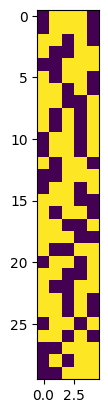




{'m_nr': 30, 't_nr': 10, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.75429903, 0.75429903, 0.75429903, 0.75429903, 0.75429903,
       0.75429903, 0.75429903, 0.75429903, 0.75429903, 0.75429903,
       0.75429903, 0.75429903, 0.75429903, 0.75429903, 0.75429903,
       0.75429903, 0.75429903, 0.75429903, 0.75429903, 0.75429903,
       0.75429903, 0.75429903, 0.75429903, 0.75429903, 0.75429903,
       0.75429903, 0.75429903, 0.75429903, 0.75429903, 0.75429903]), 'L': array([23, 19, 25, 16, 15, 15, 19, 13, 15, 16,  9, 16, 13,  6,  9, 10,  3,
       10,  9,  0,  0,  7,  6,  0,  4,  0,  2,  0,  0,  0]), 'average_A': 0.7542990312499998, 'average_L': 9.333333333333334, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.6, 'goodput_with_tag_adjustment': 0.6, 'security_goodput': 0.7542990312499998, 'rows_that_breaks_the_verification': [11, 19, 24, 26, 30]}


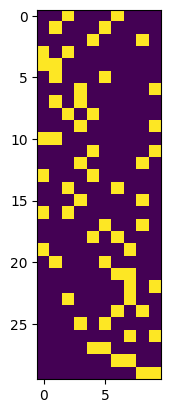




{'m_nr': 30, 't_nr': 10, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343,
       0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343,
       0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343,
       0.343, 0.343, 0.343]), 'L': array([27, 23, 25, 25, 22, 23, 17,  8, 14,  9, 15, 18,  3,  5, 10,  0, 13,
        9,  0,  3,  5,  2,  0,  0,  0,  0,  0,  0,  0,  0]), 'average_A': 0.3429999999999999, 'average_L': 9.2, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.6, 'goodput_with_tag_adjustment': 0.6, 'security_goodput': 0.3429999999999999, 'rows_that_breaks_the_verification': [3, 5, 6, 12, 14, 15, 16, 20, 21, 22]}


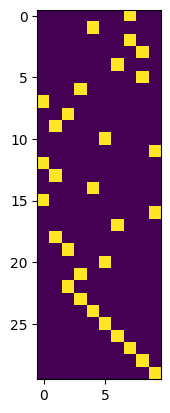




{'m_nr': 30, 't_nr': 10, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.16226147, 1.16226147, 1.16226147, 1.16226147, 1.16226147,
       1.16226147, 1.16226147, 1.16226147, 1.16226147, 1.16226147,
       1.16226147, 1.16226147, 1.16226147, 1.16226147, 1.16226147,
       1.16226147, 1.16226147, 1.16226147, 1.16226147, 1.16226147,
       1.16226147, 1.16226147, 1.16226147, 1.16226147, 1.16226147,
       1.16226147, 1.16226147, 1.16226147, 1.16226147, 1.16226147]), 'L': array([26, 21, 20, 19, 24, 21, 16, 21, 19, 18, 16, 15, 16, 13, 12, 11,  6,
       10,  4,  7,  2,  1,  0,  5,  2,  1,  0,  0,  0,  0]), 'average_A': 1.1622614670000004, 'average_L': 10.866666666666667, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.6, 'goodput_with_tag_adjustment': 0.6357615894039735, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [6, 17, 26, 28]}


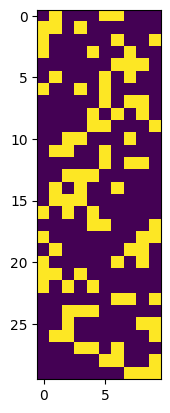




{'m_nr': 30, 't_nr': 10, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.421875, 0.421875, 0.421875, 0.421875, 0.421875, 0.421875,
       0.421875, 0.421875, 0.421875, 0.421875, 0.421875, 0.421875,
       0.421875, 0.421875, 0.421875, 0.421875, 0.421875, 0.421875,
       0.421875, 0.421875, 0.421875, 0.421875, 0.421875, 0.421875,
       0.421875, 0.421875, 0.421875, 0.421875, 0.421875, 0.421875]), 'L': array([29, 13, 22, 23, 21,  4, 20,  2, 15,  0, 18,  3, 15,  5,  0,  3, 11,
       12,  0,  9,  3,  4,  2,  0,  0,  0,  0,  0,  0,  0]), 'average_A': 0.421875, 'average_L': 7.8, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.6, 'goodput_with_tag_adjustment': 0.6, 'security_goodput': 0.421875, 'rows_that_breaks_the_verification': [1, 3, 7, 9, 10, 11, 15, 17, 19, 26]}


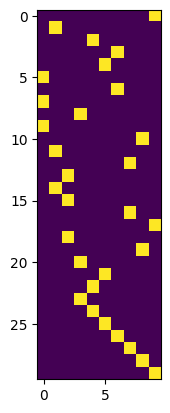




{'m_nr': 30, 't_nr': 10, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([2.38393138, 2.38393138, 2.38393138, 2.38393138, 2.38393138,
       2.38393138, 2.38393138, 2.38393138, 2.38393138, 2.38393138,
       2.38393138, 2.38393138, 2.38393138, 2.38393138, 2.38393138,
       2.38393138, 2.38393138, 2.38393138, 2.38393138, 2.38393138,
       2.38393138, 2.38393138, 2.38393138, 2.38393138, 2.38393138,
       2.38393138, 2.38393138, 2.38393138, 2.38393138, 2.38393138]), 'L': array([28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12,
       11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0,  0]), 'average_A': 2.3839313840168033, 'average_L': 13.533333333333333, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.6, 'goodput_with_tag_adjustment': 0.7820773930753564, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [6, 18]}


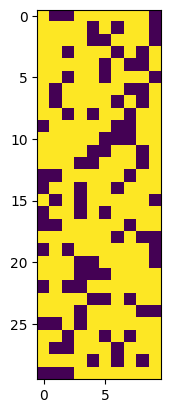




{'m_nr': 30, 't_nr': 10, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.524288, 0.524288, 0.524288, 0.524288, 0.524288, 0.524288,
       0.524288, 0.524288, 0.524288, 0.524288, 0.524288, 0.524288,
       0.524288, 0.524288, 0.524288, 0.524288, 0.524288, 0.524288,
       0.524288, 0.524288, 0.524288, 0.524288, 0.524288, 0.524288,
       0.524288, 0.524288, 0.524288, 0.524288, 0.524288, 0.524288]), 'L': array([23, 23, 23, 20, 24, 18, 23, 18, 16, 15, 13, 12, 11, 11,  9,  8,  9,
        7,  9,  4,  4,  3,  1,  0,  0,  0,  1,  0,  0,  0]), 'average_A': 0.5242880000000002, 'average_L': 10.166666666666666, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.6, 'goodput_with_tag_adjustment': 0.6, 'security_goodput': 0.5242880000000002, 'rows_that_breaks_the_verification': [7, 24, 25, 26, 29]}


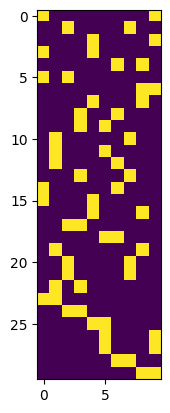




{'m_nr': 30, 't_nr': 15, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855,
       1.13144855, 1.13144855, 1.13144855, 1.13144855, 1.13144855]), 'L': array([24, 19, 20, 17, 14, 13, 12, 11, 12, 11, 12,  7, 12,  5,  6,  3,  4,
        1,  0,  1,  0,  3,  0,  3,  0,  2,  0,  0,  0,  0]), 'average_A': 1.1314485468749997, 'average_L': 7.066666666666666, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5311203319502075, 'security_goodput': 1.0, 'rows_that_breaks_the_verification': [13, 16, 18, 21, 22]}


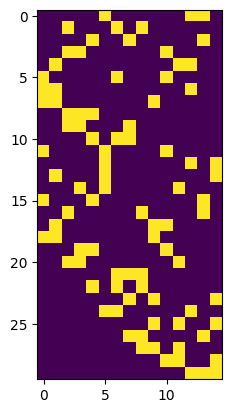




{'m_nr': 30, 't_nr': 15, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125,
       0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125, 0.6328125]), 'L': array([26, 23, 12,  8, 14,  6,  8, 19, 10,  9,  1,  0, 12, 15,  0,  3,  8,
        1,  0,  7,  4,  4,  2,  3,  0,  0,  0,  0,  0,  0]), 'average_A': 0.6328125, 'average_L': 6.5, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5, 'security_goodput': 0.6328125, 'rows_that_breaks_the_verification': [5, 6, 7, 18, 25, 27, 28, 29]}


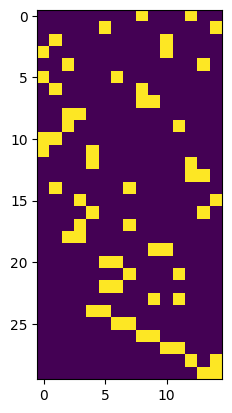




{'m_nr': 30, 't_nr': 15, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49,
       0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49,
       0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49]), 'L': array([27,  8, 12, 18, 22, 20, 22, 13, 21,  0,  5, 11, 12,  6,  0,  0,  7,
        1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]), 'average_A': 0.49, 'average_L': 6.833333333333333, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5, 'security_goodput': 0.49, 'rows_that_breaks_the_verification': [5, 10, 11, 12, 13, 15, 19, 20, 21, 22, 24, 26, 28, 29, 30]}


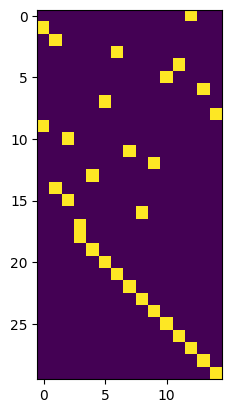




{'m_nr': 30, 't_nr': 15, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922,
       1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922, 1.7433922]), 'L': array([27, 24, 19, 18, 24, 20, 15, 14, 19, 16, 16, 10, 14,  8, 12,  6,  5,
        9,  9,  6,  1,  0,  5,  4,  3,  0,  0,  0,  0,  0]), 'average_A': 1.7433922005, 'average_L': 10.133333333333333, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.6368159203980099, 'security_goodput': 0.9999999999999999, 'rows_that_breaks_the_verification': [4, 7, 10, 24]}


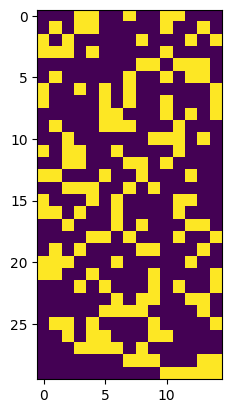




{'m_nr': 30, 't_nr': 15, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922,
       3.58485922, 3.58485922, 3.58485922, 3.58485922, 3.58485922]), 'L': array([28, 27, 26, 25, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 12,
        9,  8,  7,  8,  5,  4,  5,  2,  1,  0,  1,  0,  0]), 'average_A': 3.584859224085419, 'average_L': 12.2, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.7828746177370031, 'security_goodput': 0.9999999999999999, 'rows_that_breaks_the_verification': [5, 21]}


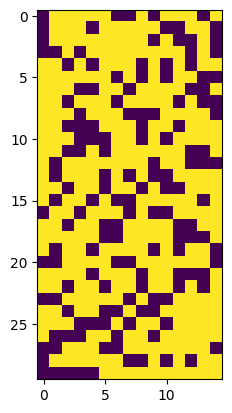




{'m_nr': 30, 't_nr': 15, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'A': array([0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192,
       0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192,
       0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192,
       0.8192, 0.8192, 0.8192, 0.8192, 0.8192, 0.8192]), 'L': array([25, 20, 19, 20, 22, 20, 16,  8,  7,  6, 12, 10, 13,  8,  9,  0,  7,
        6,  3,  3,  2,  0,  0,  0,  4,  0,  0,  0,  0,  0]), 'average_A': 0.8191999999999999, 'average_L': 8.0, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.5, 'goodput_with_tag_adjustment': 0.5, 'security_goodput': 0.8191999999999999, 'rows_that_breaks_the_verification': [1, 9, 11, 22, 24, 25, 26, 27]}


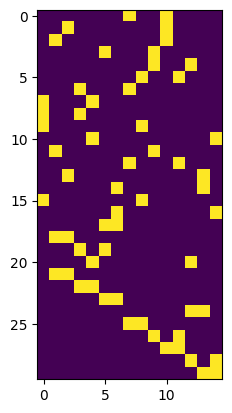




{'m_nr': 34, 't_nr': 17, 'p': 0.7, 'q': 1, 'x': 2, 'name': 'AggMAC_2'}
{'A': array([0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49,
       0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49,
       0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49, 0.49,
       0.49]), 'L': array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]), 'average_A': 0.4899999999999999, 'average_L': 0.5, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.8888888888888888, 'security_goodput': 125.43999999999997, 'rows_that_breaks_the_verification': [1, 3, 6, 7, 9, 11, 14, 15, 18, 19, 21, 23, 25, 27, 29, 32, 34]}


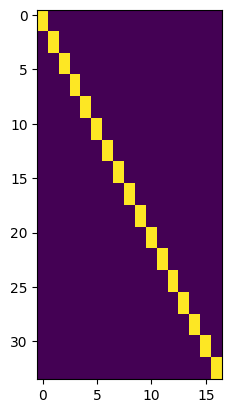




{'m_nr': 34, 't_nr': 17, 'p': 0.8, 'q': 1, 'x': 2, 'name': 'AggMAC_2'}
{'A': array([0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64,
       0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64,
       0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64,
       0.64]), 'L': array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]), 'average_A': 0.6400000000000001, 'average_L': 0.5, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.8888888888888888, 'security_goodput': 163.84000000000003, 'rows_that_breaks_the_verification': [1, 3, 6, 7, 9, 11, 14, 15, 18, 19, 21, 23, 25, 27, 29, 32, 34]}


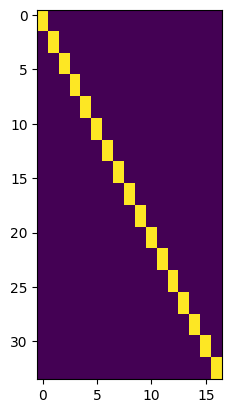




{'m_nr': 34, 't_nr': 17, 'p': 0.9, 'q': 1, 'x': 2, 'name': 'AggMAC_2'}
{'A': array([0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81,
       0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81,
       0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81,
       0.81]), 'L': array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]), 'average_A': 0.8099999999999999, 'average_L': 0.5, 'computation_(tag to message ratio)': 0.5, 'goodput_without_tag_adjustment': 0.8888888888888888, 'security_goodput': 207.35999999999999, 'rows_that_breaks_the_verification': [1, 3, 6, 7, 9, 11, 14, 15, 18, 19, 21, 23, 25, 27, 29, 32, 34]}


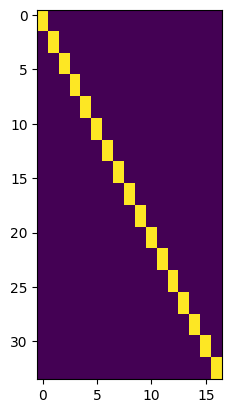




{'m_nr': 33, 't_nr': 11, 'p': 0.7, 'q': 1, 'x': 3, 'name': 'AggMAC_3'}
{'A': array([0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343,
       0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343,
       0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343, 0.343,
       0.343, 0.343, 0.343, 0.343, 0.343, 0.343]), 'L': array([2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2,
       1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0]), 'average_A': 0.3429999999999999, 'average_L': 1.0, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.9230769230769231, 'security_goodput': 87.80799999999998, 'rows_that_breaks_the_verification': [2, 4, 7, 10, 13, 18, 19, 23, 26, 28, 31]}


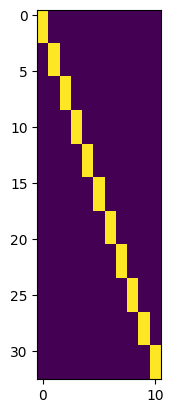




{'m_nr': 33, 't_nr': 11, 'p': 0.8, 'q': 1, 'x': 3, 'name': 'AggMAC_3'}
{'A': array([0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512,
       0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512,
       0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512, 0.512,
       0.512, 0.512, 0.512, 0.512, 0.512, 0.512]), 'L': array([2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2,
       1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0]), 'average_A': 0.5120000000000001, 'average_L': 1.0, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.9230769230769231, 'security_goodput': 131.07200000000003, 'rows_that_breaks_the_verification': [2, 4, 7, 10, 13, 18, 19, 23, 26, 28, 31]}


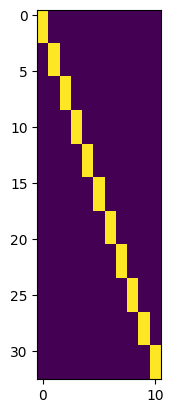




{'m_nr': 33, 't_nr': 11, 'p': 0.9, 'q': 1, 'x': 3, 'name': 'AggMAC_3'}
{'A': array([0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729,
       0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729,
       0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729, 0.729,
       0.729, 0.729, 0.729, 0.729, 0.729, 0.729]), 'L': array([2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2,
       1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0]), 'average_A': 0.7290000000000001, 'average_L': 1.0, 'computation_(tag to message ratio)': 0.3333333333333333, 'goodput_without_tag_adjustment': 0.9230769230769231, 'security_goodput': 186.62400000000002, 'rows_that_breaks_the_verification': [2, 4, 7, 10, 13, 18, 19, 23, 26, 28, 31]}


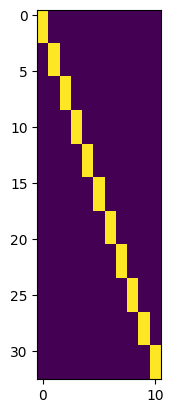




{'m_nr': 32, 't_nr': 8, 'p': 0.7, 'q': 1, 'x': 4, 'name': 'AggMAC_4'}
{'A': array([0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401,
       0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401,
       0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401,
       0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401, 0.2401]), 'L': array([3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2,
       1, 0, 3, 2, 1, 0, 3, 2, 1, 0]), 'average_A': 0.24009999999999992, 'average_L': 1.5, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.9411764705882353, 'security_goodput': 61.46559999999998, 'rows_that_breaks_the_verification': [1, 5, 12, 13, 17, 23, 28, 29]}


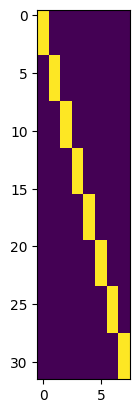




{'m_nr': 32, 't_nr': 8, 'p': 0.8, 'q': 1, 'x': 4, 'name': 'AggMAC_4'}
{'A': array([0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096,
       0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096,
       0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096,
       0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096, 0.4096]), 'L': array([3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2,
       1, 0, 3, 2, 1, 0, 3, 2, 1, 0]), 'average_A': 0.40960000000000013, 'average_L': 1.5, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.9411764705882353, 'security_goodput': 104.85760000000003, 'rows_that_breaks_the_verification': [1, 5, 12, 13, 17, 23, 28, 29]}


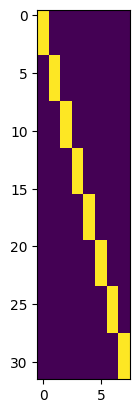




{'m_nr': 32, 't_nr': 8, 'p': 0.9, 'q': 1, 'x': 4, 'name': 'AggMAC_4'}
{'A': array([0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561,
       0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561,
       0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561,
       0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561, 0.6561]), 'L': array([3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2,
       1, 0, 3, 2, 1, 0, 3, 2, 1, 0]), 'average_A': 0.6561000000000001, 'average_L': 1.5, 'computation_(tag to message ratio)': 0.25, 'goodput_without_tag_adjustment': 0.9411764705882353, 'security_goodput': 167.96160000000003, 'rows_that_breaks_the_verification': [1, 5, 12, 13, 17, 23, 28, 29]}


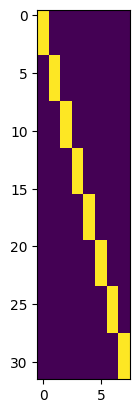




{'m_nr': 35, 't_nr': 7, 'p': 0.7, 'q': 1, 'x': 5, 'name': 'AggMAC_5'}
{'A': array([0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807,
       0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807,
       0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807,
       0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807,
       0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807, 0.16807]), 'L': array([4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3,
       2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0]), 'average_A': 0.16806999999999997, 'average_L': 2.0, 'computation_(tag to message ratio)': 0.2, 'goodput_without_tag_adjustment': 0.9523809523809523, 'security_goodput': 43.02591999999999, 'rows_that_breaks_the_verification': [2, 6, 15, 16, 25, 26, 35]}


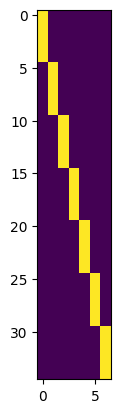




{'m_nr': 35, 't_nr': 7, 'p': 0.8, 'q': 1, 'x': 5, 'name': 'AggMAC_5'}
{'A': array([0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768,
       0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768,
       0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768,
       0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768,
       0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768, 0.32768]), 'L': array([4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3,
       2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0]), 'average_A': 0.3276800000000002, 'average_L': 2.0, 'computation_(tag to message ratio)': 0.2, 'goodput_without_tag_adjustment': 0.9523809523809523, 'security_goodput': 83.88608000000005, 'rows_that_breaks_the_verification': [2, 6, 15, 16, 25, 26, 35]}


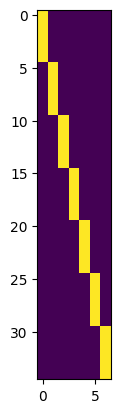




{'m_nr': 35, 't_nr': 7, 'p': 0.9, 'q': 1, 'x': 5, 'name': 'AggMAC_5'}
{'A': array([0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049,
       0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049,
       0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049,
       0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049,
       0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049, 0.59049]), 'L': array([4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0, 4, 3,
       2, 1, 0, 4, 3, 2, 1, 0, 4, 3, 2, 1, 0]), 'average_A': 0.5904900000000001, 'average_L': 2.0, 'computation_(tag to message ratio)': 0.2, 'goodput_without_tag_adjustment': 0.9523809523809523, 'security_goodput': 151.16544000000002, 'rows_that_breaks_the_verification': [2, 6, 15, 16, 25, 26, 35]}


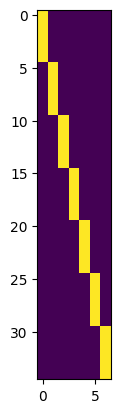




{'m_nr': 20, 't_nr': 20, 'p': 0.7, 'q': 1, 'name': 'trad'}
{'A': array([0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7,
       0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 0.6999999999999998, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8, 'security_goodput': 179.19999999999996, 'rows_that_breaks_the_verification': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


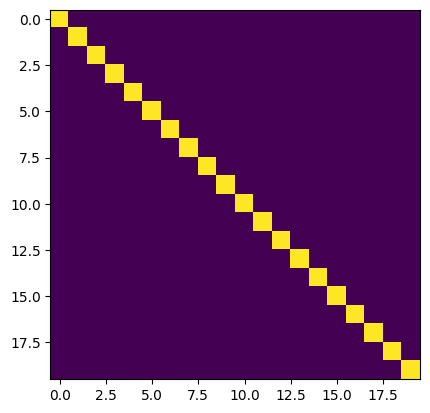




{'m_nr': 20, 't_nr': 20, 'p': 0.7, 'q': 1, 'x': 2, 'name': 'Whip_2'}
{'A': array([1.19, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98,
       0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.49]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 0.9659999999999999, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8444444444444444, 'security_goodput': 123.64799999999998, 'rows_that_breaks_the_verification': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]}


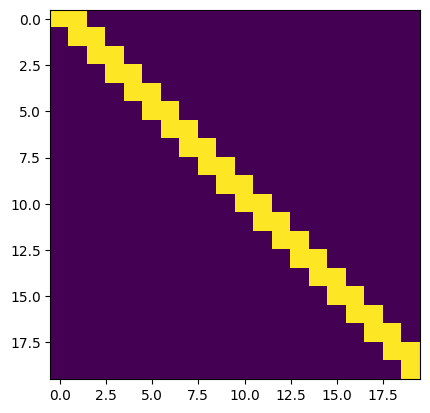




{'m_nr': 20, 't_nr': 20, 'p': 0.7, 'q': 1, 'x': 3, 'name': 'Whip_3'}
{'A': array([1.533, 1.176, 1.029, 1.029, 1.029, 1.029, 1.029, 1.029, 1.029,
       1.029, 1.029, 1.029, 1.029, 1.029, 1.029, 1.029, 1.029, 1.029,
       0.686, 0.343]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 1.0100999999999998, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8307692307692307, 'security_goodput': 86.19519999999997, 'rows_that_breaks_the_verification': [1, 4, 7, 10, 13, 16, 19]}


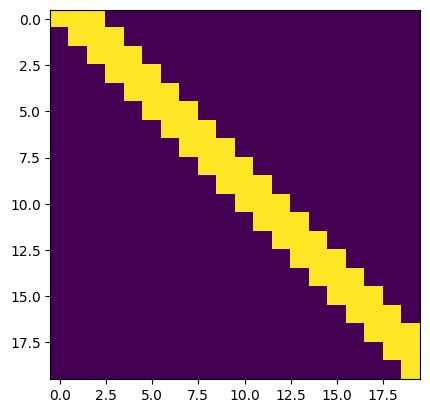




{'m_nr': 20, 't_nr': 20, 'p': 0.7, 'q': 1, 'x': 4, 'name': 'Whip_4'}
{'A': array([1.7731, 1.3132, 1.0633, 0.9604, 0.9604, 0.9604, 0.9604, 0.9604,
       0.9604, 0.9604, 0.9604, 0.9604, 0.9604, 0.9604, 0.9604, 0.9604,
       0.9604, 0.7203, 0.4802, 0.2401]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 0.9517899999999996, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8, 'security_goodput': 60.91455999999997, 'rows_that_breaks_the_verification': [1, 5, 9, 13, 17]}


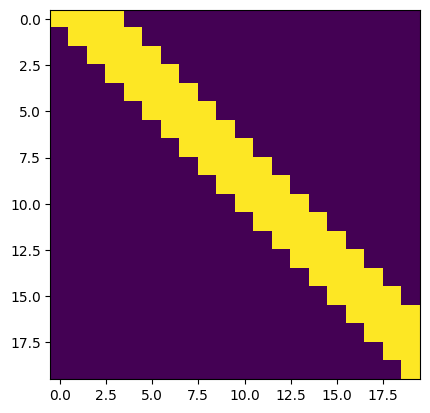




{'m_nr': 20, 't_nr': 20, 'p': 0.7, 'q': 1, 'x': 5, 'name': 'Whip_5'}
{'A': array([1.94117, 1.40924, 1.08731, 0.91238, 0.84035, 0.84035, 0.84035,
       0.84035, 0.84035, 0.84035, 0.84035, 0.84035, 0.84035, 0.84035,
       0.84035, 0.84035, 0.67228, 0.50421, 0.33614, 0.16807]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 0.8557499999999998, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.7619047619047619, 'security_goodput': 43.81439999999999, 'rows_that_breaks_the_verification': [1, 6, 11, 16]}


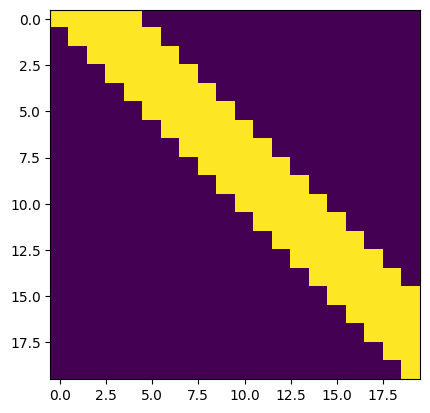




{'m_nr': 20, 't_nr': 20, 'p': 0.8, 'q': 1, 'name': 'trad'}
{'A': array([0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8,
       0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 0.8000000000000002, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8, 'security_goodput': 204.80000000000004, 'rows_that_breaks_the_verification': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


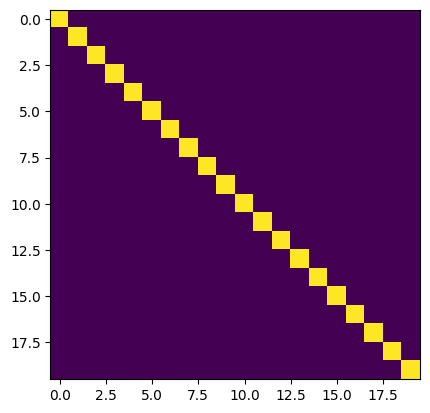




{'m_nr': 20, 't_nr': 20, 'p': 0.8, 'q': 1, 'x': 2, 'name': 'Whip_2'}
{'A': array([1.44, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28,
       1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 1.28, 0.64]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 1.2560000000000004, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8444444444444444, 'security_goodput': 160.76800000000006, 'rows_that_breaks_the_verification': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]}


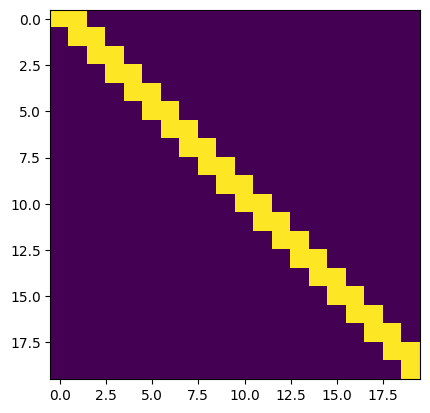




{'m_nr': 20, 't_nr': 20, 'p': 0.8, 'q': 1, 'x': 3, 'name': 'Whip_3'}
{'A': array([1.952, 1.664, 1.536, 1.536, 1.536, 1.536, 1.536, 1.536, 1.536,
       1.536, 1.536, 1.536, 1.536, 1.536, 1.536, 1.536, 1.536, 1.536,
       1.024, 0.512]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 1.4864000000000006, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8307692307692307, 'security_goodput': 126.83946666666671, 'rows_that_breaks_the_verification': [1, 4, 7, 10, 13, 16, 19]}


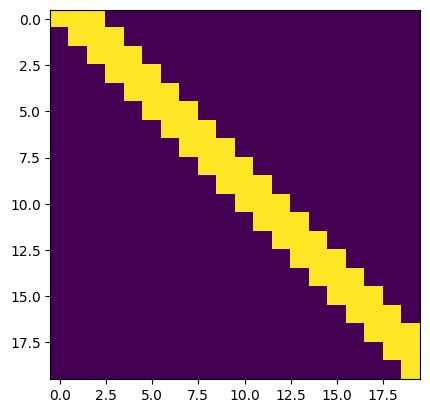




{'m_nr': 20, 't_nr': 20, 'p': 0.8, 'q': 1, 'x': 4, 'name': 'Whip_4'}
{'A': array([2.3616, 1.9712, 1.7408, 1.6384, 1.6384, 1.6384, 1.6384, 1.6384,
       1.6384, 1.6384, 1.6384, 1.6384, 1.6384, 1.6384, 1.6384, 1.6384,
       1.6384, 1.2288, 0.8192, 0.4096]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 1.5734400000000004, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8, 'security_goodput': 100.70016000000003, 'rows_that_breaks_the_verification': [1, 5, 9, 13, 17]}


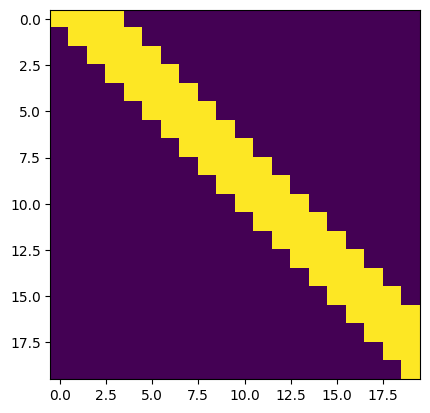




{'m_nr': 20, 't_nr': 20, 'p': 0.8, 'q': 1, 'x': 5, 'name': 'Whip_5'}
{'A': array([2.68928, 2.21696, 1.90464, 1.72032, 1.6384 , 1.6384 , 1.6384 ,
       1.6384 , 1.6384 , 1.6384 , 1.6384 , 1.6384 , 1.6384 , 1.6384 ,
       1.6384 , 1.6384 , 1.31072, 0.98304, 0.65536, 0.32768]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 1.5734400000000008, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.7619047619047619, 'security_goodput': 80.56012800000003, 'rows_that_breaks_the_verification': [1, 6, 11, 16]}


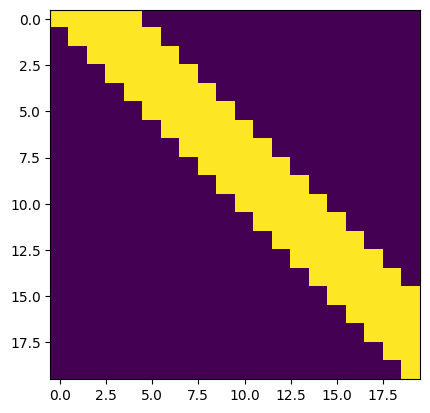




{'m_nr': 20, 't_nr': 20, 'p': 0.9, 'q': 1, 'name': 'trad'}
{'A': array([0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
       0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 0.8999999999999998, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8, 'security_goodput': 230.39999999999995, 'rows_that_breaks_the_verification': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


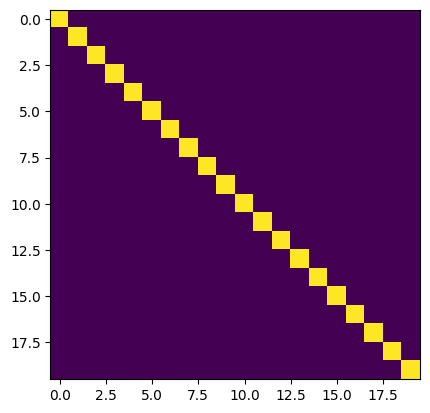




{'m_nr': 20, 't_nr': 20, 'p': 0.9, 'q': 1, 'x': 2, 'name': 'Whip_2'}
{'A': array([1.71, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62,
       1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 0.81]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 1.584, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8444444444444444, 'security_goodput': 202.752, 'rows_that_breaks_the_verification': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]}


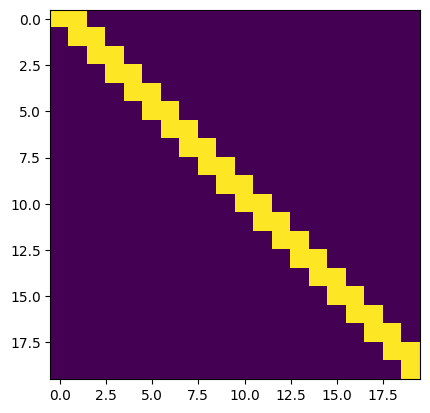




{'m_nr': 20, 't_nr': 20, 'p': 0.9, 'q': 1, 'x': 3, 'name': 'Whip_3'}
{'A': array([2.439, 2.268, 2.187, 2.187, 2.187, 2.187, 2.187, 2.187, 2.187,
       2.187, 2.187, 2.187, 2.187, 2.187, 2.187, 2.187, 2.187, 2.187,
       1.458, 0.729]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 2.0942999999999996, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8307692307692307, 'security_goodput': 178.7136, 'rows_that_breaks_the_verification': [1, 4, 7, 10, 13, 16, 19]}


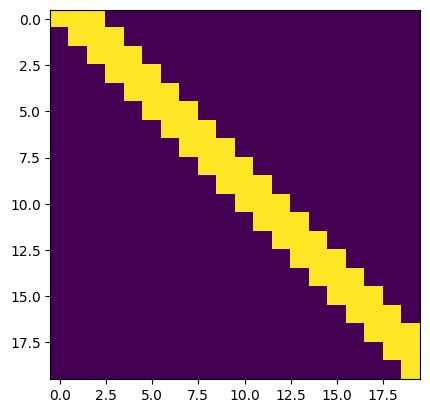




{'m_nr': 20, 't_nr': 20, 'p': 0.9, 'q': 1, 'x': 4, 'name': 'Whip_4'}
{'A': array([3.0951, 2.8512, 2.6973, 2.6244, 2.6244, 2.6244, 2.6244, 2.6244,
       2.6244, 2.6244, 2.6244, 2.6244, 2.6244, 2.6244, 2.6244, 2.6244,
       2.6244, 1.9683, 1.3122, 0.6561]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 2.4660900000000003, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.8, 'security_goodput': 157.82976000000002, 'rows_that_breaks_the_verification': [1, 5, 9, 13, 17]}


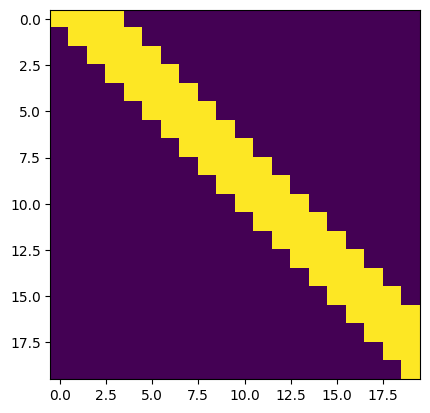




{'m_nr': 20, 't_nr': 20, 'p': 0.9, 'q': 1, 'x': 5, 'name': 'Whip_5'}
{'A': array([3.68559, 3.37608, 3.15657, 3.01806, 2.95245, 2.95245, 2.95245,
       2.95245, 2.95245, 2.95245, 2.95245, 2.95245, 2.95245, 2.95245,
       2.95245, 2.95245, 2.36196, 1.77147, 1.18098, 0.59049]), 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'average_A': 2.7285300000000006, 'average_L': 0.0, 'computation_(tag to message ratio)': 1.0, 'goodput_without_tag_adjustment': 0.7619047619047619, 'security_goodput': 139.700736, 'rows_that_breaks_the_verification': [1, 6, 11, 16]}


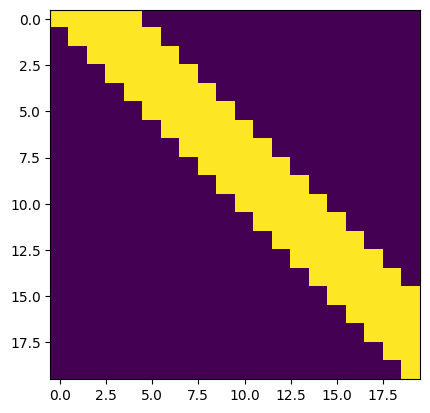

In [5]:
experiments = utils.Load_Experiments()
for exp in experiments:
    print(experiments[exp]['parameters'])
    print(experiments[exp]['eval'])
    plt.imshow(experiments[exp]['results']['X'])
    plt.show()
    print('\n\n')

### Run the optimizer With Latency

In [ ]:
parameters = {'m_nr': 10, 't_nr': 10,
                'p': 0.9, 'q': .9,
                'TagEveryMessage': True,
                'AtLeastOnce': False,
                'EquivalentA': True,
                'weight_A': 1,
                'weight_L': 0}


for i in range(10):
    exp = utils.Run_Experiment(model = model_latency.math_model,
                            parameters = parameters,
                            eval=Auth.evaluate,
                            save=True,
                            m_size=1024,
                            t_size=256)
    parameters['weight_L'] += 0.1
    print(exp['eval'])

# exp['eval']